In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke, FakeKyiv
from qiskit_ibm_runtime import SamplerV2 as Sampler
backend = FakeSherbrooke()
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator
from numpy import pi, random
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


# Exercise 1: Quantum Teleportation

In this exercise, you will implement the quantum teleportation protocol. 

**Scenario:** Alice wants to send a mystery quantum state to Bob. To achieve this, assume that Alice and Bob already share an entangled qubit pair in the Bell state: 
$|\Phi^+\rangle_{AB} = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$

**Your Tasks:**
1. **Build the Circuit:** Construct the teleportation circuit.
2. **Prepare the State:** Create a random single-qubit state to act as Alice's secret message.
3. **Ideal Simulation:** Test your protocol using a perfect, noiseless quantum simulator to verify Bob receives the correct state.
4. **Noisy Simulation:** Run the same protocol on a `FakeBackend` to observe how hardware noise impacts the teleportation fidelity.

### Here is a quantum circuit implementation of the teleportation protocol.
Insert code below the commented text

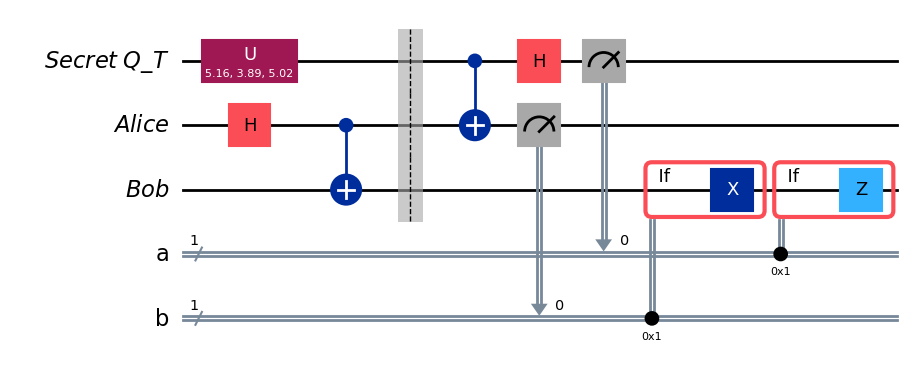

In [8]:
from qiskit.circuit.library import UGate
import numpy as np

qubit = QuantumRegister(1, "Secret Q_{T}")
ebit0 = QuantumRegister(1, "Alice")
ebit1 = QuantumRegister(1, "Bob")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")


protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# create Bell pair between Alice and Bob
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)

# a) Prepare qubit used for teleportation

theta=np.random.random()*2*np.pi
phi=np.random.random()*2*np.pi
lam=np.random.random()*2*np.pi

protocol.append(UGate(theta,phi,lam), qubit)

# instert barrier
protocol.barrier()

# b) Alice's operations
protocol.cx(qubit, ebit0)
protocol.h(qubit)

# c) Alice measures and sends classical bits to Bob
protocol.measure(qubit,a)
protocol.measure(ebit0,b)

# d) Bob uses the classical bits to conditionally apply gates (use if_test() function)
with protocol.if_test((b, 1)):
    protocol.x(ebit1)

with protocol.if_test((a, 1)):
    protocol.z(ebit1)


display(protocol.draw(output="mpl"))

### Step 1: Prepare the Secret Qubit
Create a random quantum state for Alice to teleport. Use the `UGate` class ([Qiskit UGate Documentation](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.UGate)) to apply a gate with random parameters $U(\theta, \phi, \lambda)$ to the $|0\rangle_T$ qubit. 

The resulting state will be the secret message: $U(\theta, \phi, \lambda)|0\rangle = |\psi\rangle_T$.

In [ ]:
#Already everything is in the above cell

# from qiskit.circuit.library import UGate
# import numpy as np

# theta=np.random.random()*2*np.pi
# phi=np.random.random()*2*np.pi
# lam=np.random.random()*2*np.pi

# protocol.append(
#     UGate(theta,phi,lam),
#     qubit
# )

### Step 2: Ideal Simulation
Run your completed teleportation circuit using an ideal, noiseless simulator. Compare the initial state vector of Alice's secret qubit with Bob's final qubit to verify that the teleportation was successful.

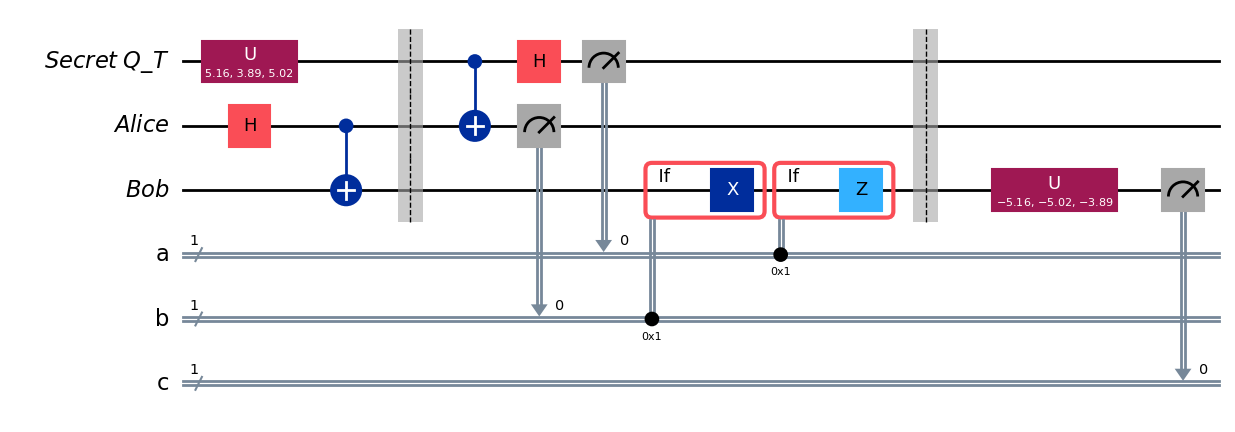

{'0 0 0': 258, '0 0 1': 266, '0 1 0': 255, '0 1 1': 245}
Counter({'0': 1024})


In [ ]:
# Create a new circuit including the same bits and qubits used in the
# teleportation protocol.
from qiskit_aer import AerSimulator


c = ClassicalRegister(1, "c")
test = QuantumCircuit(qubit, ebit0, ebit1, a, b, c) #additional classical register c for Bob measurement

test = test.compose(protocol)


test.barrier()

test.append(
    UGate(theta, phi, lam).inverse(), # we add U inversed, because U'|psi> =  U'U|0> = |0>
    ebit1                             # so if teleportation works fine, bob will always measure 0
)

test.measure(ebit1, c)

display(test.draw(output="mpl"))

sim = AerSimulator()
result = sim.run(test, shots=1024).result()
counts = result.get_counts()
print(counts)


from collections import Counter

bob_counts = Counter()

for key, value in counts.items(): # we filter the results to see only what Bob measures in c
    c_value = key.split()[0]
    bob_counts[c_value] += value

print("Bob counts")
print(bob_counts)


from qiskit.quantum_info import Statevector

sv = Statevector(test)
amplitudes_bob = sv.data  # wektor amplitud
print("Amplitudy Boba:", amplitudes_bob)



### Step 3: Noisy Simulation (Fake Backend)
Real quantum computers have noise and decoherence. Run your circuit again, but this time use a `FakeBackend` (e.g., `FakeSherbrooke`) to simulate a real IBM Quantum device. Observe how the noise affects the measurement outcomes.


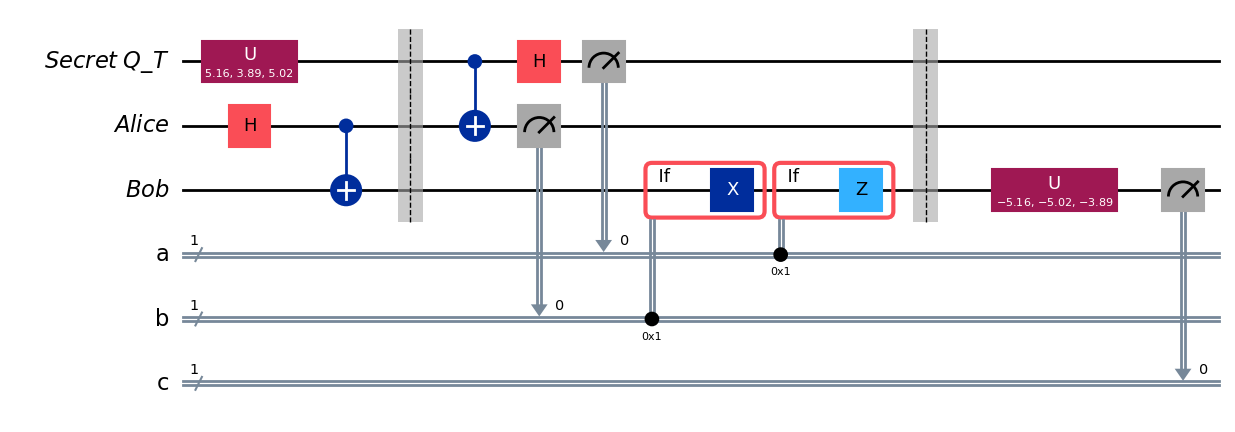

{'0 1 0': 238, '0 1 1': 265, '0 0 0': 272, '0 0 1': 225, '1 1 0': 7, '1 1 1': 9, '1 0 0': 5, '1 0 1': 3}
Bob counts noisy
Counter({'0': 1000, '1': 24})


In [18]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit import transpile
from collections import Counter

backend = FakeSherbrooke()

c = ClassicalRegister(1, "c")
test_noisy = QuantumCircuit(qubit, ebit0, ebit1, a, b, c)

test_noisy = test_noisy.compose(protocol)

test_noisy.barrier()

test_noisy.append(
    UGate(theta, phi, lam).inverse(),
    ebit1
)

test_noisy.measure(ebit1, c)

display(test_noisy.draw(output="mpl"))

sim_noisy = AerSimulator.from_backend(backend)

transpiled_test_noisy = transpile(test_noisy, sim_noisy)

result_noisy = sim_noisy.run(transpiled_test_noisy, shots=1024).result()
counts_noisy = result_noisy.get_counts()

print(counts_noisy)

bob_counts_noisy = Counter()

for key, value in counts_noisy.items():
    c_value = key.split()[0]
    bob_counts_noisy[c_value] += value

print("Bob counts noisy")
print(bob_counts_noisy)

# Exercise 2: Superdense Coding

In this exercise, you will implement the superdense coding protocol, which is the inverse of quantum teleportation. 

**Scenario:** Alice wants to transmit *two* classical bits of information to Bob by sending him only *one* qubit. Just like in teleportation, assume Alice and Bob share an entangled pair in the state:
$|\Phi^+\rangle_{AB} = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$

**Your Tasks:**
1. **Implement the Protocol:** Construct the circuit for superdense coding.
2. **Test the Combinations:** Verify your protocol works for all four possible two-bit classical messages: `00`, `01`, `10`, and `11`.
3. **Ideal vs. Noisy:** Run the tests on both a noiseless simulator and a `FakeBackend`.

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

alice = QuantumRegister(1, "Alice")
bob = QuantumRegister(1, "Bob")
c = ClassicalRegister(2, "c")

qc = QuantumCircuit(alice, bob, c)

message = "10"

qc.h(alice)
qc.cx(alice, bob)

qc.barrier()

if message[1] == "1":
    qc.x(alice)

if message[0] == "1":
    qc.z(alice)

qc.barrier()

qc.cx(alice, bob)
qc.h(alice)

qc.measure(alice, c[1])
qc.measure(bob, c[0])

display(qc.draw(output="mpl"))

sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)

*Insert your circuit implementation below:*

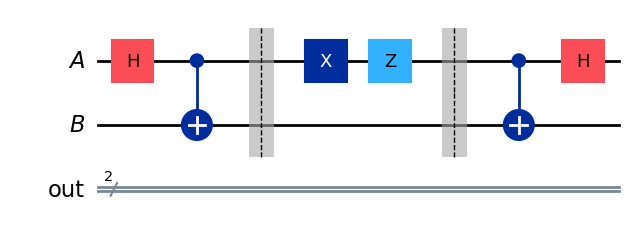

Bob ideal measurement
{'11': 1024}
Bob noisy measurement
{'11': 986, '10': 19, '01': 13, '00': 6}


In [26]:
c = "1"
d = "1"

ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

c_out = ClassicalRegister(2, "out") # for Bob measurement

protocol = QuantumCircuit(ebit0, ebit1, c_out)

# Prepare ebit used for superdense coding
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)

protocol.barrier()

# Alice's operations
if d == "1":
    protocol.x(ebit0)

if c == "1":
    protocol.z(ebit0)

protocol.barrier()

# Bob's actions
protocol.cx(ebit0, ebit1)
protocol.h(ebit0)

display(protocol.draw(output="mpl"))


protocol.measure(ebit0, c_out[1])
protocol.measure(ebit1, c_out[0])

from qiskit_aer import AerSimulator

sim = AerSimulator()

result = sim.run(protocol, shots=1024).result()

counts = result.get_counts()

print("Bob ideal measurement")
print(counts)


from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit import transpile

backend = FakeSherbrooke()

sim_noisy = AerSimulator.from_backend(backend)

transpiled_protocol = transpile(protocol, sim_noisy)

result_noisy = sim_noisy.run(
    transpiled_protocol,
    shots=1024
).result()

counts_noisy = result_noisy.get_counts()

print("Bob noisy measurement")
print(counts_noisy)

### Step 2: Dynamic Message Generation
Instead of hardcoding the classical bits, let's make the protocol dynamic. Add an additional qubit to act as a random number generator (a quantum coin flip). Use this qubit to randomly determine the states of classical bits `c` and `d`, and then pass them through your superdense coding protocol.

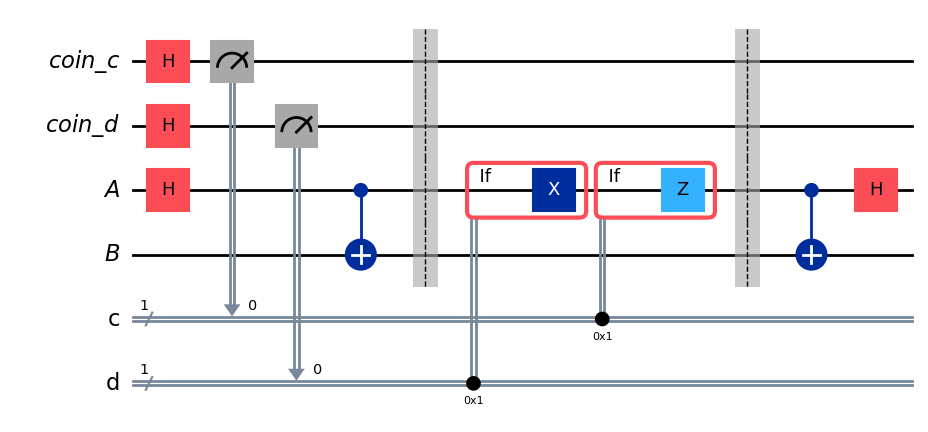

In [ ]:
#I think that we need two coin flips

coin_c = QuantumRegister(1, "coin_c")
coin_d = QuantumRegister(1, "coin_d")

c = ClassicalRegister(1, "c")
d = ClassicalRegister(1, "d")

ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

protocol = QuantumCircuit(coin_c, coin_d, ebit0, ebit1, c, d)

protocol.h(coin_c)
protocol.h(coin_d)
protocol.measure(coin_c, c)
protocol.measure(coin_d, d)

# Prepare ebit used for superdense coding
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)

protocol.barrier()

# Alice's operations
with protocol.if_test((d, 1)):
    protocol.x(ebit0)

with protocol.if_test((c, 1)):
    protocol.z(ebit0)

protocol.barrier()

# Bob's actions
protocol.cx(ebit0, ebit1)
protocol.h(ebit0)

display(protocol.draw(output="mpl"))

### Step 3: Noisy Simulation (Fake Backend)
Test your dynamic superdense coding circuit using a `FakeBackend`. Evaluate how errors and gate infidelities alter the probability of Bob decoding the correct classical message.

In [ ]:
#already done in previous steps

# Homework Assignments

1. **Complete Lab Tasks:** Ensure all code cells from today's class are fully implemented and running without errors.
2. **Protocol Variations:** We used the $|\Phi^+\rangle$ Bell state for today's protocols. How would the teleportation and superdense coding protocols change if Alice and Bob shared a *different* Bell state instead (e.g., $|\Psi^+\rangle = \frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$)? 
   * *Hint: Think about what additional gates Alice or Bob might need to apply to correct the final state.*

3. **Bonus Challenge (Voluntary): Testing the CHSH Inequality** Dive deeper into the nature of quantum entanglement by testing the CHSH inequality, a famous theorem demonstrating that quantum mechanics is incompatible with local hidden-variable theories. 

   **Your Tasks:**
   * **Reference:** Read through the official [Qiskit CHSH Inequality Tutorial](https://quantum.cloud.ibm.com/docs/en/tutorials/chsh-inequality) to understand the setup.
   * **Implementation:** Design the parameterized circuits required to measure the CHSH observable.
   * **Ideal vs. Noisy:** Run your circuits on a perfect simulator first to calculate the ideal expectation value. Then, run the same circuits on a `FakeBackend`.
   * **Analysis:** Compare the results. Does your noisy simulation still violate the classical limit (where the absolute value of S is less than or equal to 2), or does the hardware noise destroy the quantum correlation?


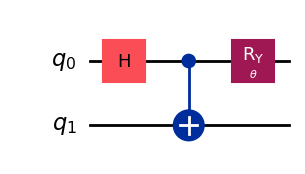

In [28]:
# General
import numpy as np

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Qiskit Runtime imports
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator

# Plotting routines
import matplotlib.pyplot as plt
import matplotlib.ticker as tck


theta = Parameter("$\\theta$")

chsh_circuit = QuantumCircuit(2)
chsh_circuit.h(0)
chsh_circuit.cx(0, 1)
chsh_circuit.ry(theta, 0)
chsh_circuit.draw(output="mpl", idle_wires=False, style="iqp")

In [29]:
number_of_phases = 21
phases = np.linspace(0, 2 * np.pi, number_of_phases)
# Phases need to be expressed as list of lists in order to work
individual_phases = [[ph] for ph in phases]

In [ ]:
# <CHSH1> = <AB> - <Ab> + <aB> + <ab> -> <ZZ> - <ZX> + <XZ> + <XX>
observable1 = SparsePauliOp.from_list(
    [("ZZ", 1), ("ZX", -1), ("XZ", 1), ("XX", 1)]
)

# <CHSH2> = <AB> + <Ab> - <aB> + <ab> -> <ZZ> + <ZX> - <XZ> + <XX>
observable2 = SparsePauliOp.from_list(
    [("ZZ", 1), ("ZX", 1), ("XZ", -1), ("XX", 1)])

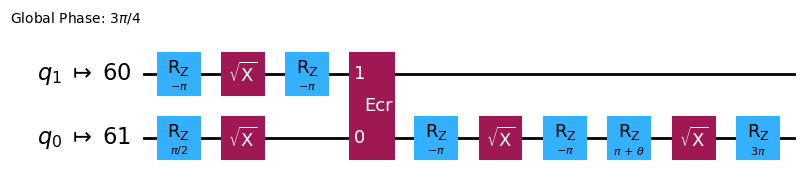

In [32]:
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

chsh_isa_circuit = pm.run(chsh_circuit)
chsh_isa_circuit.draw(output="mpl", idle_wires=False, style="iqp")

In [33]:
isa_observable1 = observable1.apply_layout(layout=chsh_isa_circuit.layout)
isa_observable2 = observable2.apply_layout(layout=chsh_isa_circuit.layout)

In [37]:
from qiskit.primitives import StatevectorEstimator

ideal_estimator = StatevectorEstimator()

ideal_pub = (
    chsh_circuit,
    [[observable1], [observable2]],
    individual_phases,
)

ideal_result = ideal_estimator.run([ideal_pub]).result()

ideal_values = ideal_result[0].data.evs

ideal_chsh1 = ideal_values[0]
ideal_chsh2 = ideal_values[1]

In [41]:
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

fake_backend = FakeSherbrooke()

pm_noisy = generate_preset_pass_manager(
    target=fake_backend.target,
    optimization_level=0
)

chsh_noisy_circuit = pm_noisy.run(chsh_circuit)

noisy_observable1 = observable1.apply_layout(
    chsh_noisy_circuit.layout
)

noisy_observable2 = observable2.apply_layout(
    chsh_noisy_circuit.layout
)

noise_model = NoiseModel.from_backend(fake_backend)

noisy_estimator = AerEstimator(
    options={
        "backend_options": {
            "noise_model": noise_model
        }
    }
)

noisy_pub = (
    chsh_noisy_circuit,
    [[noisy_observable1], [noisy_observable2]],
    individual_phases,
)

noisy_result = noisy_estimator.run(
    [noisy_pub]
).result()

noisy_values = noisy_result[0].data.evs

noisy_chsh1 = noisy_values[0]
noisy_chsh2 = noisy_values[1]

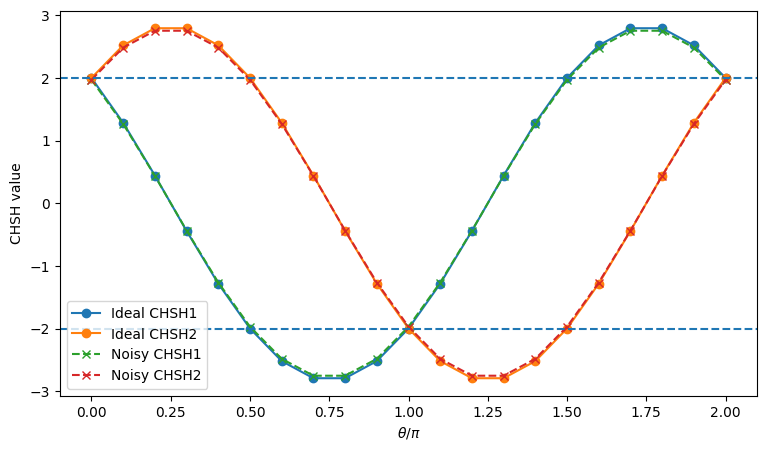

In [42]:
plt.figure(figsize=(9, 5))

plt.plot(phases / np.pi, ideal_chsh1, "o-", label="Ideal CHSH1")
plt.plot(phases / np.pi, ideal_chsh2, "o-", label="Ideal CHSH2")

plt.plot(phases / np.pi, noisy_chsh1, "x--", label="Noisy CHSH1")
plt.plot(phases / np.pi, noisy_chsh2, "x--", label="Noisy CHSH2")

plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.xlabel(r"$\theta / \pi$")
plt.ylabel("CHSH value")
plt.legend()
plt.show()

In [43]:
ideal_max = max(
    np.max(np.abs(ideal_chsh1)),
    np.max(np.abs(ideal_chsh2))
)

noisy_max = max(
    np.max(np.abs(noisy_chsh1)),
    np.max(np.abs(noisy_chsh2))
)

print("Ideal max |S| =", ideal_max)
print("Noisy max |S| =", noisy_max)

if noisy_max > 2:
    print("Noisy simulation still violates the classical CHSH limit.")
else:
    print("Noise destroys the CHSH violation.")

Ideal max |S| = 2.7936044933348407
Noisy max |S| = 2.7535987040811096
Noisy simulation still violates the classical CHSH limit.
